# 🔍 Proyecto: Detección de Fraude con Tarjetas de Crédito
---

## 📋 Objetivo del Notebook

Este notebook corresponde a la etapa de:

# Análisis Exploratorio de Datos (EDA)

El objetivo principal es comprender:
- la estructura del dataset,
- la calidad de los datos,
- posibles patrones de fraude,
- variables importantes,
- y desafíos del problema antes del modelado.

Durante este análisis:
- cargaremos los datasets,
- realizaremos un merge de tablas,
- estudiaremos el desbalanceo de clases,
- analizaremos valores faltantes,
- y visualizaremos variables relevantes.

El EDA es una etapa crítica porque permite:
- detectar problemas tempranos,
- definir estrategias de preprocesamiento,
- y orientar el desarrollo del modelo de Machine Learning.

## 💳 Contexto del Problema

El fraude financiero representa uno de los principales desafíos
para bancos, fintechs y plataformas de pago digitales.

Detectar fraudes correctamente es importante porque:
- reduce pérdidas económicas,
- protege usuarios,
- y mejora la seguridad de los sistemas financieros.

Sin embargo, este problema presenta varias dificultades:

### ⚠️ Desafíos principales

- Los fraudes son extremadamente raros.
- Los datos están altamente desbalanceados.
- Existen muchas variables faltantes.
- Algunos patrones son complejos y difíciles de detectar.

Por ello, más adelante utilizaremos:
- técnicas de balanceo como SMOTE,
- modelos avanzados como XGBoost,
- y herramientas de interpretabilidad como SHAP.

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import gc

warnings.filterwarnings('ignore')

# Configuración visual
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Mostrar todas las columnas
pd.set_option('display.max_columns', None)

# Liberar memoria
gc.collect()

print("✅ Librerías cargadas correctamente")

✅ Librerías cargadas correctamente


## 📂 Descripción del Dataset

El dataset utilizado proviene de la competencia:

### IEEE-CIS Fraud Detection (Kaggle)

Contiene información de:
- transacciones financieras,
- identidad del usuario,
- dispositivos,
- direcciones,
- y variables anonimizadas.

### Archivos principales

#### `train_transaction.csv`
Contiene:
- 590,540 transacciones
- 394 columnas

La variable objetivo es:
- `isFraud`
    - 0 → transacción legítima
    - 1 → fraude

#### `train_identity.csv`
Contiene:
- información adicional de identidad
- datos de dispositivo y usuario

No todas las transacciones tienen información de identidad.

# 📉 Reducción del Dataset para Desarrollo

Debido al gran tamaño del dataset original
(590K+ transacciones), utilizaremos un subconjunto
aleatorio para acelerar el análisis y reducir
consumo de memoria.

La muestra mantiene la distribución general
del problema y permite iterar más rápidamente
durante la etapa de desarrollo.

In [ ]:
# ============================================
# Columnas útiles
# ============================================

columnas_numericas = [
    'TransactionAmt',
    'TransactionDT',
    'card1',
    'card2',
    'card3',
    'addr1',
    'addr2',
    'dist1',
    'dist2'
]

columnas_c = [f'C{i}' for i in range(1, 15)]

columnas_d = [f'D{i}' for i in range(1, 16)]

columnas_categoricas = [
    'ProductCD',
    'card4',
    'card6',
    'P_emaildomain',
    'R_emaildomain'
]

columnas_id = [f'id_{i:02d}' for i in range(1, 39)]

# ============================================
# Columnas para cada archivo
# ============================================

cols_trans = (
    ['TransactionID', 'isFraud']
    + columnas_numericas
    + columnas_c
    + columnas_d
    + columnas_categoricas
)

cols_id = (
    ['TransactionID']
    + columnas_id
    + ['DeviceType', 'DeviceInfo']
)

# ============================================
# Cargar CSV
# ============================================

print("📥 Cargando transacciones...")

df_trans = pd.read_csv(
    '../data/raw/train_transaction.csv',
    usecols=cols_trans
)

print(df_trans.shape)

print("\n📥 Cargando identidades...")

df_id = pd.read_csv(
    '../data/raw/train_identity.csv',
    usecols=cols_id
)

print(df_id.shape)

📥 Cargando transacciones...
(590540, 45)

📥 Cargando identidades...
(144233, 41)


## 🔗 Unión de Tablas (Merge)

Ambos datasets comparten la columna:

### `TransactionID`

La unión se realiza utilizando:

```python
how='left'
```

Esto significa que:
- conservaremos TODAS las transacciones,
- incluso aquellas que no tengan datos de identidad.

### ¿Por qué es importante?

Porque no queremos perder información valiosa
del dataset principal.

Las transacciones sin identidad quedarán
con valores `NaN` en las columnas correspondientes.

In [ ]:
print("\n🔗 Uniendo tablas...")

df = pd.merge(
    df_trans,
    df_id,
    on='TransactionID',
    how='left'
)

print(df.shape)


🔗 Uniendo tablas...
(590540, 85)


In [ ]:
print("\n📉 Reduciendo tamaño para desarrollo...")

df = df.sample(
    frac=0.1,
    random_state=42
).reset_index(drop=True)

print(df.shape)

# Liberar memoria
del df_trans, df_id
gc.collect()

df.head()

# 📊 Información General del Dataset

Analizaremos:
- tipos de variables,
- cantidad de columnas,
- consumo de memoria,
- y presencia de valores faltantes.

df.info()

# ⚖️ Desbalanceo de Clases

En problemas de fraude:
- la mayoría de transacciones son legítimas,
- y muy pocas corresponden a fraude.

Esto representa un problema importante porque:
- un modelo podría predecir siempre “no fraude”
  y aun así obtener alta accuracy.

Por eso:
- utilizaremos métricas como Recall y F2-score,
- y técnicas como SMOTE más adelante.

In [ ]:
fraudes = df['isFraud'].sum()
total = len(df)

print(
    f"Fraudes: {fraudes} ({fraudes/total:.4%})"
)

print(
    f"Legítimos: {total-fraudes} ({(total-fraudes)/total:.4%})"
)

NameError: name 'df' is not defined

In [ ]:
sns.countplot(
    x='isFraud',
    data=df
)

plt.title(
    'Distribución de clases'
)

plt.xlabel(
    'Clase'
)

plt.ylabel(
    'Cantidad'
)

plt.show()

## 🧩 Valores Nulos

Muchas variables contienen datos faltantes.

Esto puede deberse a:
- diferencias entre usuarios,
- ausencia de información,
- privacidad,
- o características opcionales.

Los valores faltantes son importantes porque:
- pueden afectar el rendimiento del modelo,
- generar sesgos,
- o incluso contener información útil.

Más adelante evaluaremos:
- imputación,
- eliminación,
- o generación de indicadores de ausencia.

In [ ]:
# Porcentaje de nulos
nulos = df.isnull().mean() * 100

# Ordenar
nulos_ordenados = nulos.sort_values(ascending=False)

print("📌 Top 20 columnas con más nulos:")

print(nulos_ordenados.head(20))

Porcentaje de nulos por columna (primeras 20):
id_24    99.196159
id_25    99.130965
id_07    99.127070
id_08    99.127070
id_21    99.126393
id_26    99.125715
id_27    99.124699
id_23    99.124699
id_22    99.124699
dist2    93.628374
D7       93.409930
id_18    92.360721
D13      89.509263
D14      89.469469
D12      89.041047
id_04    88.768923
id_03    88.768923
D6       87.606767
id_33    87.589494
id_09    87.312290
dtype: float64


## 💰 Análisis de `TransactionAmt`

El monto de la transacción puede ser
una variable muy importante para detectar fraude.

### Posibles patrones

- montos extremadamente altos,
- compras inusuales,
- transacciones pequeñas repetitivas,
- o comportamientos atípicos.

Usaremos escala logarítmica porque:
- existen valores extremos,
- y la distribución es muy sesgada.

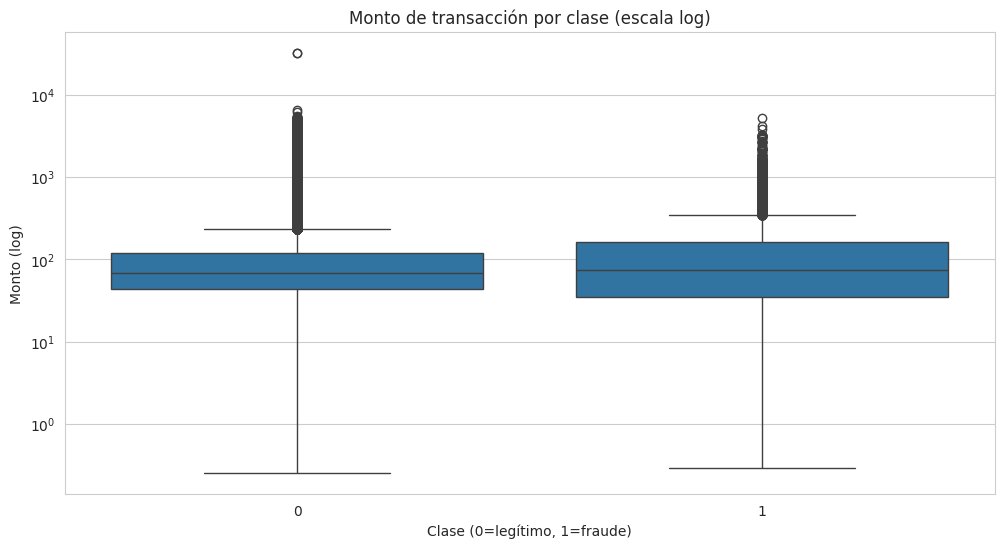

In [ ]:
plt.figure()

sns.boxplot(
    x='isFraud',
    y='TransactionAmt',
    data=df
)

plt.yscale('log')

plt.title('Monto de transacción por clase')

plt.xlabel('Clase (0=legítimo, 1=fraude)')

plt.ylabel('Monto (escala log)')

plt.show()

In [ ]:
plt.figure()

sns.histplot(
    data=df,
    x='TransactionAmt',
    hue='isFraud',
    bins=50,
    log_scale=True
)

plt.title('Distribución de montos')

plt.xlabel('Monto')

plt.ylabel('Frecuencia')

plt.show()

## 📌 Observaciones Iniciales

A partir de las visualizaciones podemos observar:

- diferencias en los montos entre clases,
- presencia de valores extremos,
- distribuciones altamente sesgadas,
- y posibles patrones asociados al fraude.

La variable `TransactionAmt`
probablemente tendrá alta importancia predictiva.

# ✅ Conclusiones del EDA

Durante este análisis exploratorio identificamos:

- un fuerte desbalanceo de clases,
- una gran cantidad de valores faltantes,
- variables potencialmente predictivas,
- y presencia de outliers importantes.

También comprendimos:
- la estructura general del dataset,
- los principales desafíos del problema,
- y posibles estrategias de preprocesamiento.

## 🚀 Próxima Etapa del Proyecto

En el siguiente notebook desarrollaremos
la etapa completa de preparación y modelado,
incluyendo:

- limpieza y transformación de datos,
- tratamiento de valores faltantes,
- feature engineering,
- codificación de variables categóricas,
- balanceo de clases con SMOTE,
- entrenamiento de modelos de Machine Learning,
- comparación de estrategias,
- y evaluación mediante métricas especializadas
  para datasets desbalanceados.

El objetivo será construir un pipeline robusto
capaz de detectar transacciones fraudulentas
de manera eficiente.